# 🧠 Alzheimer’s Disease Classification Using Machine Learning

Alzheimer’s disease is a progressive neurodegenerative disorder that affects memory, cognition, and daily functioning. Early detection is crucial for improving patient outcomes, enabling timely interventions, and supporting long‑term care planning. With the availability of clinical, lifestyle, and cognitive assessment data, machine learning provides a powerful approach to identifying early indicators of Alzheimer’s disease.

This notebook focuses on building a classification model that predicts whether a patient is diagnosed with Alzheimer’s disease based on a rich set of features, including:

### **Demographic & Background Information**
- Age, Gender, Ethnicity, EducationLevel  
- PatientID, DoctorInCharge  

### **Lifestyle & Behavioral Factors**
- Smoking, AlcoholConsumption, PhysicalActivity  
- DietQuality, SleepQuality  

### **Medical History & Comorbidities**
- FamilyHistoryAlzheimers, CardiovascularDisease, Diabetes  
- Depression, HeadInjury, Hypertension  

### **Clinical Measurements**
- BMI, SystolicBP, DiastolicBP  
- CholesterolTotal, CholesterolLDL, CholesterolHDL, CholesterolTriglycerides  

### **Cognitive & Functional Assessments**
- MMSE, FunctionalAssessment, ADL  
- MemoryComplaints, BehavioralProblems  
- Confusion, Disorientation, PersonalityChanges  
- DifficultyCompletingTasks, Forgetfulness  

### 🎯 **Target Variable**
- **Diagnosis** — indicating whether the patient has Alzheimer’s disease.

---

## 📌 Project Objectives

- Perform exploratory data analysis (EDA) to understand patterns and relationships  
- Clean and preprocess the dataset (missing values, encoding, scaling)  
- Handle class imbalance using SMOTE or class weights  
- Build baseline and advanced machine learning models  
- Optimize performance through hyperparameter tuning and threshold adjustments  
- Evaluate models using metrics such as Recall, Precision, F1‑score, ROC‑AUC  
- Identify key features contributing to Alzheimer’s prediction  
- Present insights that support early screening and clinical decision‑making  




In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")



### 📦 Description of Imported Packages

- **pandas (pd)**  
  Used for loading, cleaning, transforming, and analyzing structured data. It provides DataFrame and Series objects that make data manipulation intuitive and efficient.

- **numpy (np)**  
  Supports numerical computations, array operations, and mathematical functions. Many ML algorithms and pandas operations rely on NumPy under the hood.

- **matplotlib.pyplot (plt)**  
  A foundational plotting library used to create static visualizations such as line plots, bar charts, histograms, and scatter plots. Ideal for basic EDA.

- **seaborn (sns)**  
  Built on top of Matplotlib, it provides more attractive and informative statistical visualizations. Useful for heatmaps, distributions, boxplots, and correlation analysis.

- **warnings**  
  Used to suppress unnecessary warning messages during execution. Helps keep the notebook output clean and focused on relevant results.
  

In [13]:
df=pd.read_csv("data\\alzheimers_disease_data.csv")
df.head()

,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis,DoctorInCharge
0,4751,73,0,0,2,22.927749,0,13.297218,6.327112,1.347214,...,0,0,1.725883,0,0,0,1,0,0,XXXConfid
1,4752,89,0,0,0,26.827681,0,4.542524,7.619885,0.518767,...,0,0,2.592424,0,0,0,0,1,0,XXXConfid
2,4753,73,0,3,1,17.795882,0,19.555085,7.844988,1.826335,...,0,0,7.119548,0,1,0,1,0,0,XXXConfid
3,4754,74,1,0,1,33.800817,1,12.209266,8.428001,7.435604,...,0,1,6.481226,0,0,0,0,0,0,XXXConfid
4,4755,89,0,0,0,20.716974,0,18.454356,6.310461,0.795498,...,0,0,0.014691,0,0,1,1,0,0,XXXConfid


### 📥 Loading the Dataset

The dataset containing patient demographic, lifestyle, clinical, and cognitive assessment information is loaded using `pandas.read_csv()`. This step initializes the data analysis workflow by importing the Alzheimer’s disease dataset into a pandas DataFrame, enabling further exploration, preprocessing, and modeling.

The file `alzheimers_disease_data.csv` includes all relevant features required for building a machine learning model to predict Alzheimer’s diagnosis.

## Understanding the Dataset

In [14]:
df.columns

Index(['PatientID', 'Age', 'Gender', 'Ethnicity', 'EducationLevel', 'BMI',
       'Smoking', 'AlcoholConsumption', 'PhysicalActivity', 'DietQuality',
       'SleepQuality', 'FamilyHistoryAlzheimers', 'CardiovascularDisease',
       'Diabetes', 'Depression', 'HeadInjury', 'Hypertension', 'SystolicBP',
       'DiastolicBP', 'CholesterolTotal', 'CholesterolLDL', 'CholesterolHDL',
       'CholesterolTriglycerides', 'MMSE', 'FunctionalAssessment',
       'MemoryComplaints', 'BehavioralProblems', 'ADL', 'Confusion',
       'Disorientation', 'PersonalityChanges', 'DifficultyCompletingTasks',
       'Forgetfulness', 'Diagnosis', 'DoctorInCharge'],
      dtype='str')

### 🗂️ Dataset Feature Overview

The dataset contains a comprehensive set of demographic, lifestyle, medical, clinical, and cognitive assessment features used to predict Alzheimer’s disease diagnosis. Below is a structured breakdown of all columns:

---

## 👤 Demographic & Background Information
- **PatientID** — Unique identifier for each patient  
- **Age** — Patient’s age  
- **Gender** — Male/Female/Other  
- **Ethnicity** — Ethnic background  
- **EducationLevel** — Highest level of education attained  
- **DoctorInCharge** — Treating physician or assigned doctor  

---

## 🏃 Lifestyle & Behavioral Factors
- **Smoking** — Smoking habits or status  
- **AlcoholConsumption** — Frequency/level of alcohol intake  
- **PhysicalActivity** — Level of physical activity  
- **DietQuality** — Nutritional quality of diet  
- **SleepQuality** — Quality of sleep patterns  

---

## 🩺 Medical History & Comorbidities
- **FamilyHistoryAlzheimers** — Whether Alzheimer’s runs in the family  
- **CardiovascularDisease** — Presence of cardiovascular conditions  
- **Diabetes** — Diabetes diagnosis  
- **Depression** — Depression history  
- **HeadInjury** — Past head injuries  
- **Hypertension** — High blood pressure diagnosis  

---

## 🫀 Clinical Measurements
- **BMI** — Body Mass Index  
- **SystolicBP** — Systolic blood pressure  
- **DiastolicBP** — Diastolic blood pressure  
- **CholesterolTotal** — Total cholesterol  
- **CholesterolLDL** — LDL cholesterol  
- **CholesterolHDL** — HDL cholesterol  
- **CholesterolTriglycerides** — Triglyceride levels  

---

## 🧠 Cognitive & Functional Assessments
- **MMSE** — Mini-Mental State Examination score  
- **FunctionalAssessment** — Functional ability evaluation  
- **ADL** — Activities of Daily Living score  
- **MemoryComplaints** — Self‑reported or observed memory issues  
- **BehavioralProblems** — Behavioral or psychological symptoms  
- **Confusion** — Episodes of confusion  
- **Disorientation** — Difficulty with orientation  
- **PersonalityChanges** — Changes in personality or behavior  
- **DifficultyCompletingTasks** — Trouble finishing tasks  
- **Forgetfulness** — Frequency of forgetfulness  

---

## 🎯 Target Variable
- **Diagnosis** — Indicates whether the patient is diagnosed with Alzheimer’s disease (target variable)



In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2149 entries, 0 to 2148
Data columns (total 35 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   PatientID                  2149 non-null   int64  
 1   Age                        2149 non-null   int64  
 2   Gender                     2149 non-null   int64  
 3   Ethnicity                  2149 non-null   int64  
 4   EducationLevel             2149 non-null   int64  
 5   BMI                        2149 non-null   float64
 6   Smoking                    2149 non-null   int64  
 7   AlcoholConsumption         2149 non-null   float64
 8   PhysicalActivity           2149 non-null   float64
 9   DietQuality                2149 non-null   float64
 10  SleepQuality               2149 non-null   float64
 11  FamilyHistoryAlzheimers    2149 non-null   int64  
 12  CardiovascularDisease      2149 non-null   int64  
 13  Diabetes                   2149 non-null   int64  
 14  Dep

### 📊 Dataset Structure Summary

The dataset contains **2149 patient records** and **35 features**, covering demographic information, lifestyle habits, medical history, clinical measurements, cognitive assessments, and the final Alzheimer’s diagnosis.

All columns are complete with **no missing values**, making the dataset ready for exploratory data analysis and preprocessing.

---

## 📁 Column Types Overview

- **22 Integer Features (int64)**  
  Mostly categorical or binary indicators such as Gender, Smoking, Diabetes, Hypertension, and several cognitive/behavioral symptoms.

- **12 Float Features (float64)**  
  Continuous clinical measurements such as BMI, cholesterol levels, blood pressure, MMSE score, and ADL.

- **1 Object Feature (object)**  
  - **DoctorInCharge** — categorical text field representing the physician responsible for the patient.

---

## 📌 Key Observations

- The dataset is **clean**, with all 2149 entries having non‑null values across all features.
- All the necessary features are **numeric**, which simplifies preprocessing and model training.
- The presence of many binary medical and cognitive indicators makes this dataset suitable for tree‑based models and logistic regression.
- The target variable **Diagnosis** is an integer (likely 0/1), appropriate for binary classification.
- The only non‑numeric column (**DoctorInCharge**) will require encoding if included in the model.



In [40]:
categorical_features = [
    'Gender','Ethnicity','EducationLevel'
]

binary_features = [
    'Smoking','Diabetes','Depression',
    'Hypertension','CardiovascularDisease',
    'HeadInjury','FamilyHistoryAlzheimers',
    'MemoryComplaints','BehavioralProblems',
    'Confusion','Disorientation',
    'PersonalityChanges',
    'DifficultyCompletingTasks',
    'Forgetfulness'
]

continuous_features = [
    'Age','BMI','AlcoholConsumption',
    'PhysicalActivity','DietQuality',
    'SleepQuality','SystolicBP',
    'DiastolicBP','CholesterolTotal',
    'CholesterolLDL','CholesterolHDL',
    'CholesterolTriglycerides',
    'MMSE','FunctionalAssessment',
    'ADL'
]
habitual_features = [
    'Smoking',
    'Diabetes',
    'Depression',
    'Hypertension',
    'CardiovascularDisease',
    'HeadInjury',
    'FamilyHistoryAlzheimers'
]
symptom_features = [
    'MemoryComplaints',
    'Confusion',
    'Disorientation',
    'Forgetfulness',
    'BehavioralProblems',
    'PersonalityChanges',
    'DifficultyCompletingTasks'
]


In [17]:
df.isnull().sum()

PatientID                    0
Age                          0
Gender                       0
Ethnicity                    0
EducationLevel               0
BMI                          0
Smoking                      0
AlcoholConsumption           0
PhysicalActivity             0
DietQuality                  0
SleepQuality                 0
FamilyHistoryAlzheimers      0
CardiovascularDisease        0
Diabetes                     0
Depression                   0
HeadInjury                   0
Hypertension                 0
SystolicBP                   0
DiastolicBP                  0
CholesterolTotal             0
CholesterolLDL               0
CholesterolHDL               0
CholesterolTriglycerides     0
MMSE                         0
FunctionalAssessment         0
MemoryComplaints             0
BehavioralProblems           0
ADL                          0
Confusion                    0
Disorientation               0
PersonalityChanges           0
DifficultyCompletingTasks    0
Forgetfu

### Observation

- The dataset contains **35 features** and **no missing values** across any column.
- Data quality appears good, with no immediate need for missing value treatment.
- Features include demographic, lifestyle, medical, cognitive, and behavioral indicators relevant to Alzheimer's disease prediction.
- `PatientID` and `DoctorInCharge` are likely non-informative features and will be further evaluated for removal during preprocessing.

In [34]:
df.duplicated().sum()

np.int64(0)

### Observation

- No duplicate records were found in the dataset.
- Each patient record appears to be unique.

In [19]:
df.shape

(2149, 35)

In [27]:
df.describe()

,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,FunctionalAssessment,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis
count,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,...,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000
mean,5825.000000,74.908795,0.506282,0.697534,1.286645,27.655697,0.288506,10.039442,4.920202,4.993138,...,5.080055,0.208004,0.156817,4.982958,0.205212,0.158213,0.150768,0.158678,0.301536,0.353653
std,620.507185,8.990221,0.500077,0.996128,0.904527,7.217438,0.453173,5.757910,2.857191,2.909055,...,2.892743,0.405974,0.363713,2.949775,0.403950,0.365026,0.357906,0.365461,0.459032,0.478214
min,4751.000000,60.000000,0.000000,0.000000,0.000000,15.008851,0.000000,0.002003,0.003616,0.009385,...,0.000460,0.000000,0.000000,0.001288,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5288.000000,67.000000,0.000000,0.000000,1.000000,21.611408,0.000000,5.139810,2.570626,2.458455,...,2.566281,0.000000,0.000000,2.342836,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,5825.000000,75.000000,1.000000,0.000000,1.000000,27.823924,0.000000,9.934412,4.766424,5.076087,...,5.094439,0.000000,0.000000,5.038973,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,6362.000000,83.000000,1.000000,1.000000,2.000000,33.869778,1.000000,15.157931,7.427899,7.558625,...,7.546981,0.000000,0.000000,7.581490,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000
max,6899.000000,90.000000,1.000000,3.000000,3.000000,39.992767,1.000000,19.989293,9.987429,9.998346,...,9.996467,1.000000,1.000000,9.999747,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


### Observation

- The dataset contains **2,149 patient records** with demographic, lifestyle, clinical, cognitive, and behavioral features.
- Patients are aged between **60 and 90 years**, with an average age of approximately **75 years**.
- Continuous variables such as **BMI, Alcohol Consumption, Physical Activity, Diet Quality, MMSE, Functional Assessment, and ADL** show a wide range of values, indicating good variability for model learning.
- Binary features (e.g., Smoking, Diabetes, Depression, Memory Complaints) are encoded as **0 and 1**, making them suitable for machine learning algorithms.
- No obvious anomalies are observed from the summary statistics; however, outlier analysis will be performed in subsequent steps.
- `PatientID` appears to be a unique identifier and is unlikely to contribute to prediction performance.

## EDA

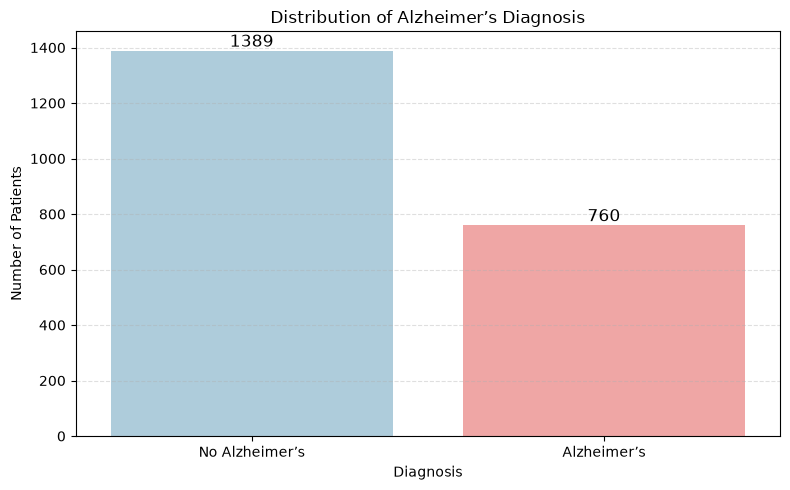

In [37]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=df,
    x='Diagnosis',
    palette=['#A6CEE3', '#FB9A99']
)

plt.xticks(
    ticks=[0,1],
    labels=['No Alzheimer’s', 'Alzheimer’s']
)

plt.xlabel('Diagnosis')
plt.ylabel('Number of Patients')

plt.title('Distribution of Alzheimer’s Diagnosis')

# Add value labels
for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom',
        fontsize=12
    )

plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

### Observation

- The target variable shows a moderate class imbalance.
- Out of 2,149 patients, **1,389 (64.6%)** are diagnosed as **No Alzheimer's**, while **760 (35.4%)** are diagnosed as **Alzheimer's**.
- Although the imbalance is not severe, it should be considered during model development and evaluation.
- Performance metrics such as **Recall, F1-Score, and ROC-AUC** will be more informative than Accuracy alone.
- Techniques such as **class weighting** or **SMOTE** may be explored during model training to address the imbalance.

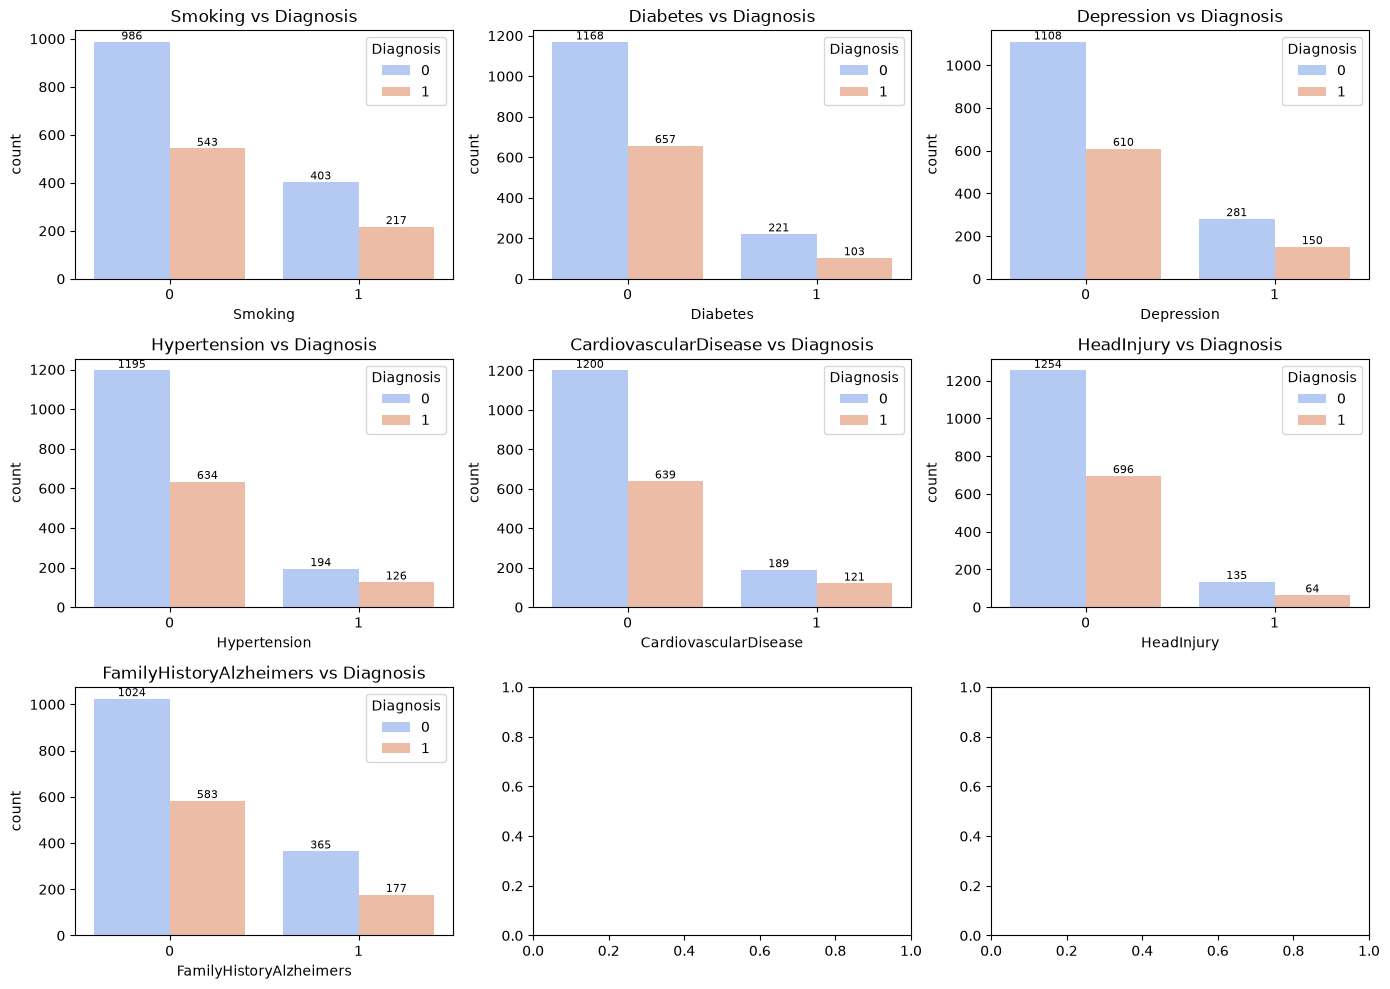

In [38]:

fig, axes = plt.subplots(3, 3, figsize=(14, 10))

axes = axes.flatten()

for i, col in enumerate(habitual_features):

    sns.countplot(
        data=df,
        x=col,
        hue='Diagnosis',
        palette='coolwarm',
        ax=axes[i]
    )

    axes[i].set_title(f'{col} vs Diagnosis')

    # Add count labels
    for container in axes[i].containers:
        axes[i].bar_label(container, fmt='%d', fontsize=8)
    
    # Hide unused subplots
    for j in range(len(binary_features), len(axes)):
        axes[j].set_visible(False)

plt.tight_layout()
plt.show()

### Observation

- Most patients in the dataset do not have a history of smoking, diabetes, depression, hypertension, cardiovascular disease, head injury, or family history of Alzheimer's.
- Across all variables, the **non-Alzheimer's group (Diagnosis = 0)** has a higher count than the **Alzheimer's group (Diagnosis = 1)**, consistent with the overall class distribution.
- A noticeable proportion of Alzheimer's cases is observed among patients with a **family history of Alzheimer's**, suggesting it may be an important predictor.
- The relationship between these health conditions and Alzheimer's diagnosis is not conclusive from count plots alone and will require further statistical analysis and feature importance evaluation during modeling.

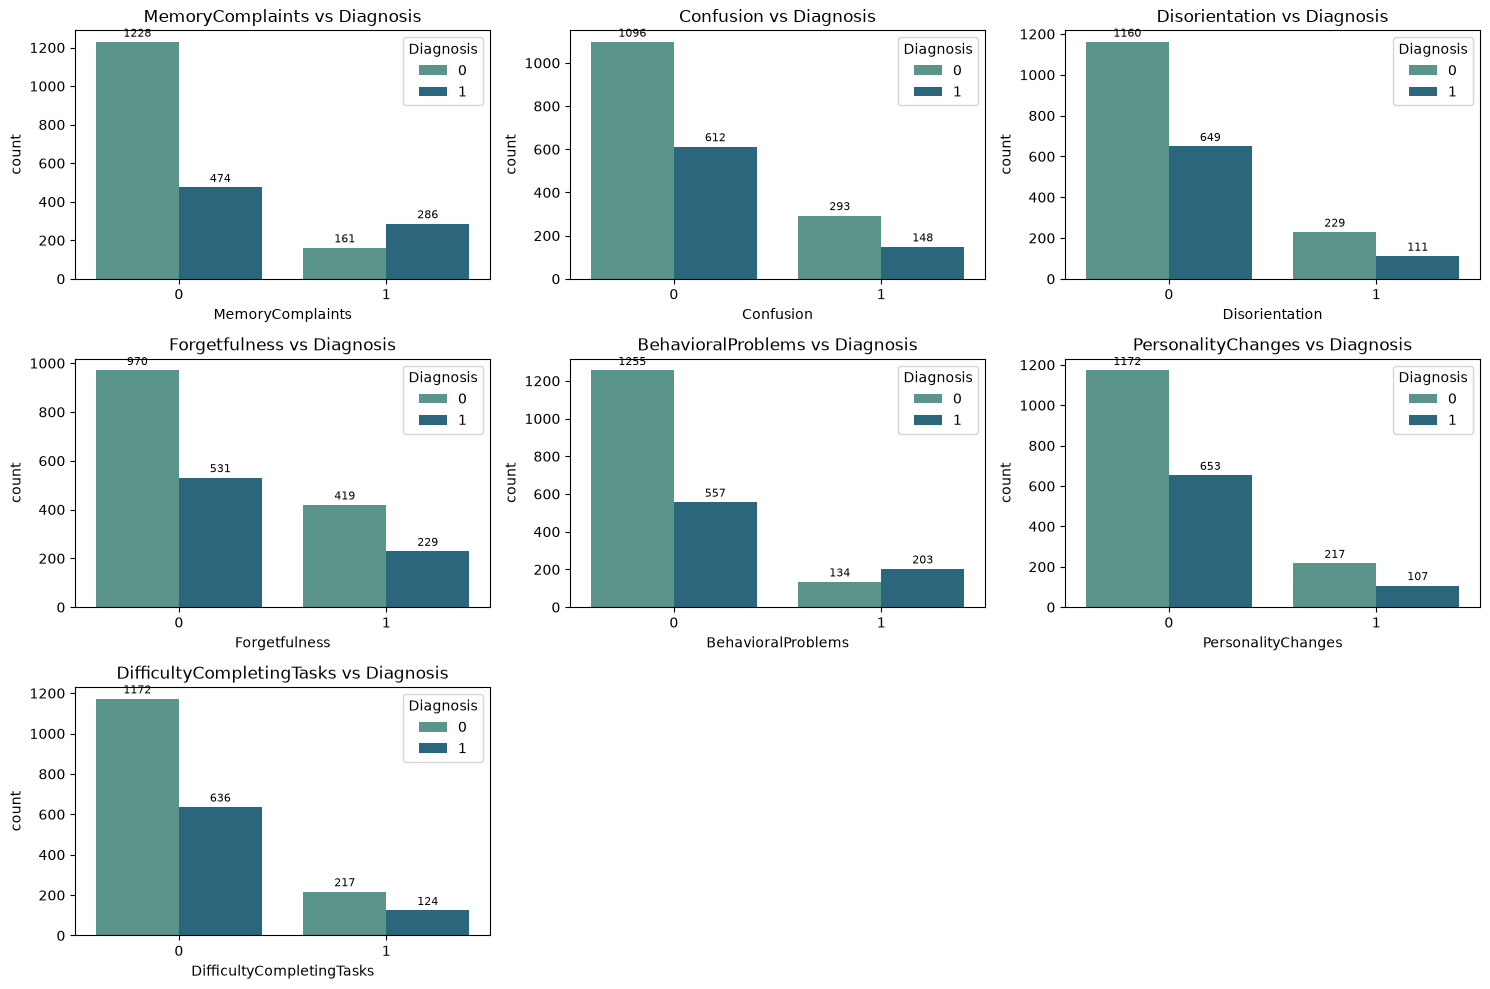

In [ ]:

fig, axes = plt.subplots(3, 3, figsize=(15, 10))

axes = axes.flatten()

for i, col in enumerate(symptom_features):

    sns.countplot(
        data=df,
        x=col,
        hue='Diagnosis',
        palette='crest',
        ax=axes[i]
    )

    axes[i].set_title(f'{col} vs Diagnosis')

    # Add count labels
    for container in axes[i].containers:
        axes[i].bar_label(
            container,
            fmt='%d',
            fontsize=8,
            padding=2
        )

# Hide unused subplots
for j in range(len(symptom_features), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

### Observation

- Several symptom-related features show a noticeable relationship with Alzheimer's diagnosis.
- Patients reporting **Memory Complaints** and **Behavioral Problems** exhibit a relatively higher proportion of Alzheimer's diagnoses compared to those without these symptoms.
- Features such as **Confusion, Disorientation, Personality Changes, Forgetfulness, and Difficulty Completing Tasks** also demonstrate differences in diagnosis distribution, indicating potential predictive value.
- These variables represent cognitive and behavioral symptoms commonly associated with Alzheimer's disease and are likely to contribute significantly during model training.
- Since these features may directly reflect manifestations of Alzheimer's, they should be carefully assessed for potential target leakage when developing an Early Alzheimer's Risk Detection model.

In [26]:
pd.crosstab(
    df['MemoryComplaints'],
    df['Diagnosis'],
    normalize='index'
) * 100

Diagnosis,0,1
MemoryComplaints,,
0,72.150411,27.849589
1,36.017897,63.982103


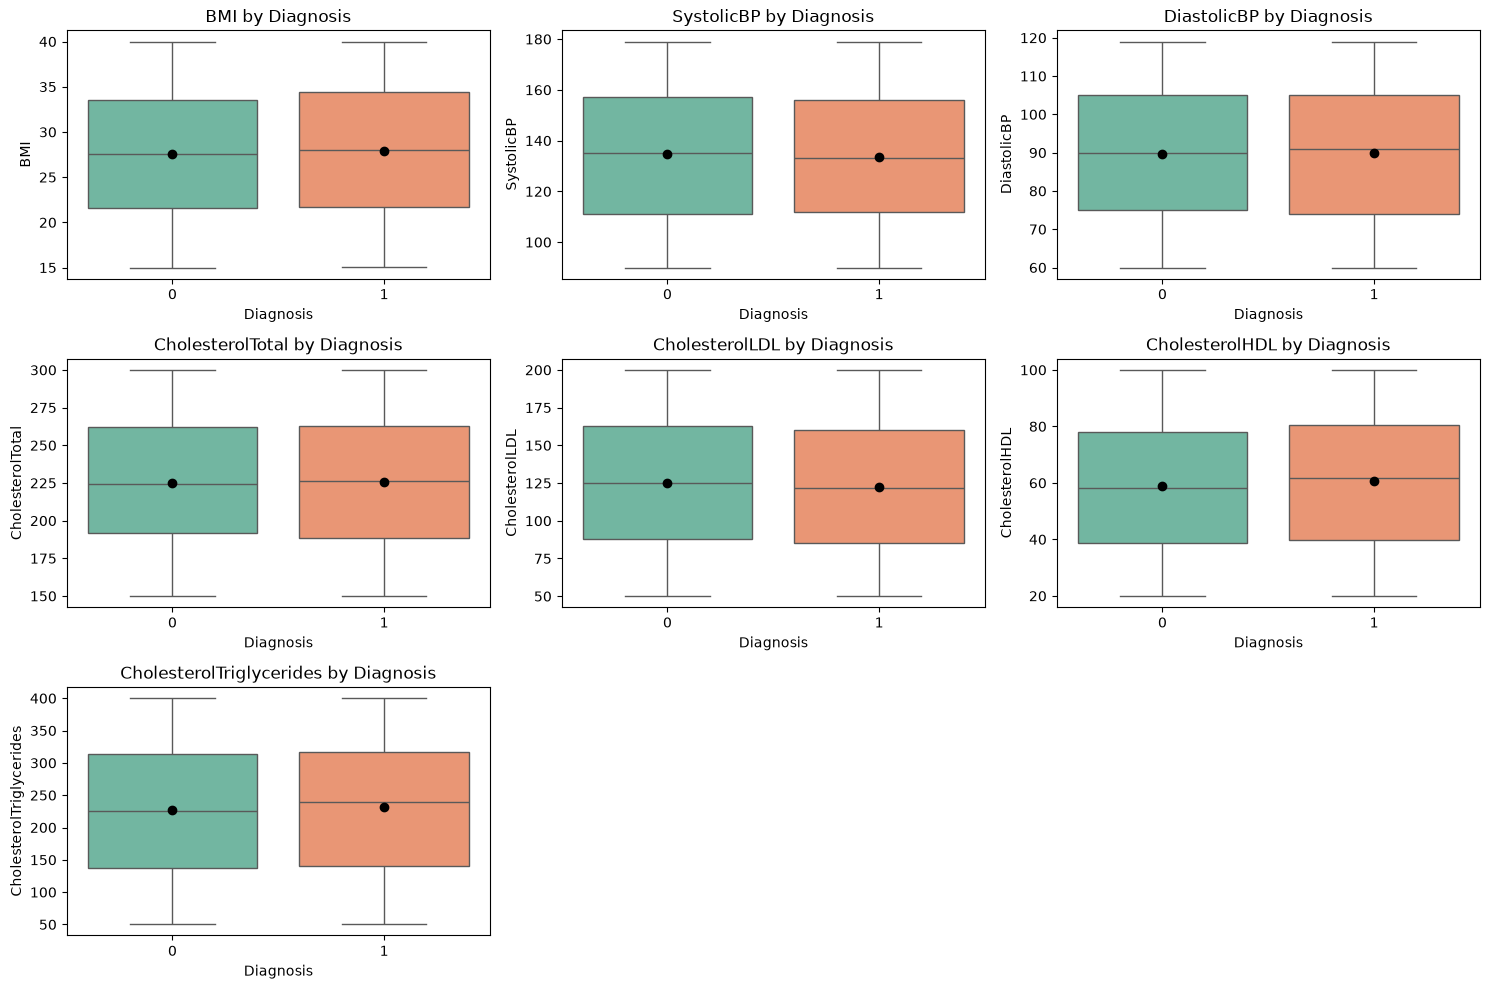

In [29]:
biomarker_features = [
    'BMI',
    'SystolicBP',
    'DiastolicBP',
    'CholesterolTotal',
    'CholesterolLDL',
    'CholesterolHDL',
    'CholesterolTriglycerides'
]

fig, axes = plt.subplots(3, 3, figsize=(15, 10))

axes = axes.flatten()

for i, col in enumerate(biomarker_features):

    sns.boxplot(
        data=df,
        x='Diagnosis',
        y=col,
        hue='Diagnosis',
        palette='Set2',
        showmeans=True,
        meanprops={
            'marker': 'o',
            'markerfacecolor': 'black',
            'markeredgecolor': 'black'
        },
        legend=False,
        ax=axes[i]
    )

    axes[i].set_title(f'{col} by Diagnosis')
# Hide unused subplots
for j in range(len(biomarker_features), len(axes)):
    axes[j].set_visible(False)
plt.tight_layout()
plt.show()


### Observation

- The distributions of BMI, Blood Pressure, and Cholesterol-related features are largely similar across both diagnosis groups.
- Median values and interquartile ranges (IQRs) show substantial overlap between patients with and without Alzheimer's disease.
- No strong separation is observed in these variables when comparing Alzheimer's and non-Alzheimer's patients.
- Most features exhibit relatively symmetric distributions with few or no extreme outliers.
- These health indicators may still contribute to prediction when combined with other variables, but individually they do not appear to be strong discriminators of Alzheimer's diagnosis.
- Further analysis using correlation measures and feature importance techniques will help determine their predictive significance.

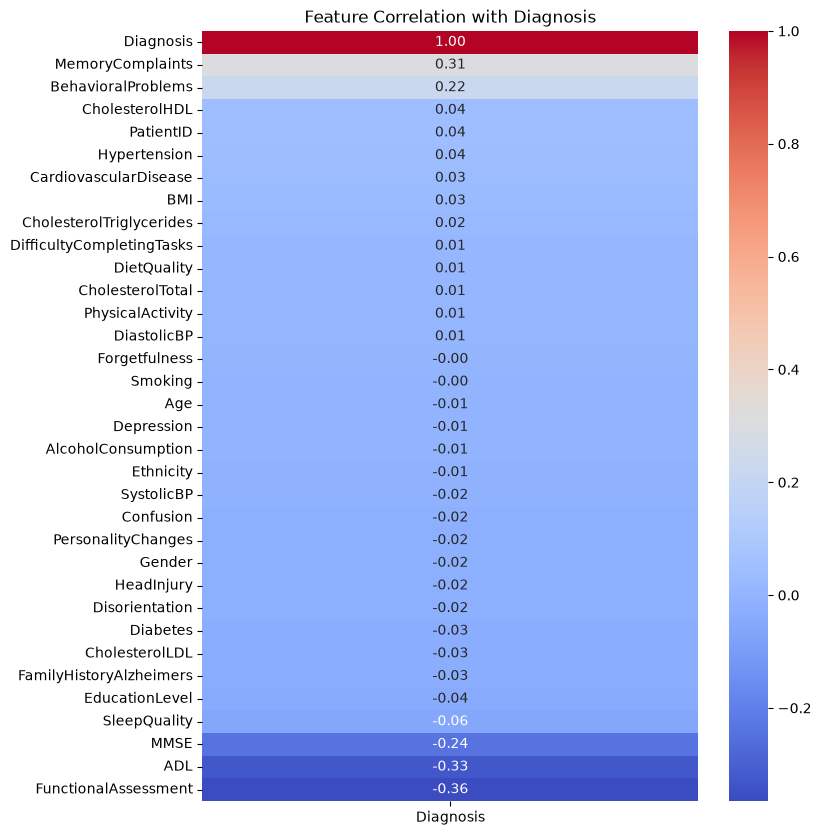

In [30]:
corr_target = (
    df.corr(numeric_only=True)['Diagnosis']
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 10))

sns.heatmap(
    corr_target.to_frame(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Feature Correlation with Diagnosis')

plt.show()

### Observation

- **FunctionalAssessment (-0.36)**, **ADL (-0.33)**, and **MMSE (-0.24)** exhibit the strongest correlations with Alzheimer's diagnosis.
- **MemoryComplaints (0.31)** and **BehavioralProblems (0.22)** show the highest positive correlations with the target variable.
- Most demographic, lifestyle, and cardiovascular-related features have weak correlations (|r| < 0.10), suggesting limited individual linear relationships with the diagnosis.
- The correlation analysis indicates that cognitive and functional assessment measures are more strongly associated with Alzheimer's diagnosis than general health indicators.
- Features with low individual correlation may still contribute to model performance when combined with other variables and should not be excluded solely based on correlation values.

In [31]:
# Select only numerical columns
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
# Compute correlation with churn
corr_with_churn = df[num_cols].corr()['Diagnosis'].sort_values(ascending=False)

corr_with_churn

Diagnosis                    1.000000
MemoryComplaints             0.306742
BehavioralProblems           0.224350
CholesterolHDL               0.042584
PatientID                    0.041019
Hypertension                 0.035080
CardiovascularDisease        0.031490
BMI                          0.026343
CholesterolTriglycerides     0.022672
DifficultyCompletingTasks    0.009069
DietQuality                  0.008506
CholesterolTotal             0.006394
PhysicalActivity             0.005945
DiastolicBP                  0.005293
Forgetfulness               -0.000354
Smoking                     -0.004865
Age                         -0.005488
Depression                  -0.005893
AlcoholConsumption          -0.007618
Ethnicity                   -0.014782
SystolicBP                  -0.015615
Confusion                   -0.019186
PersonalityChanges          -0.020627
Gender                      -0.020975
HeadInjury                  -0.021411
Disorientation              -0.024648
Diabetes    

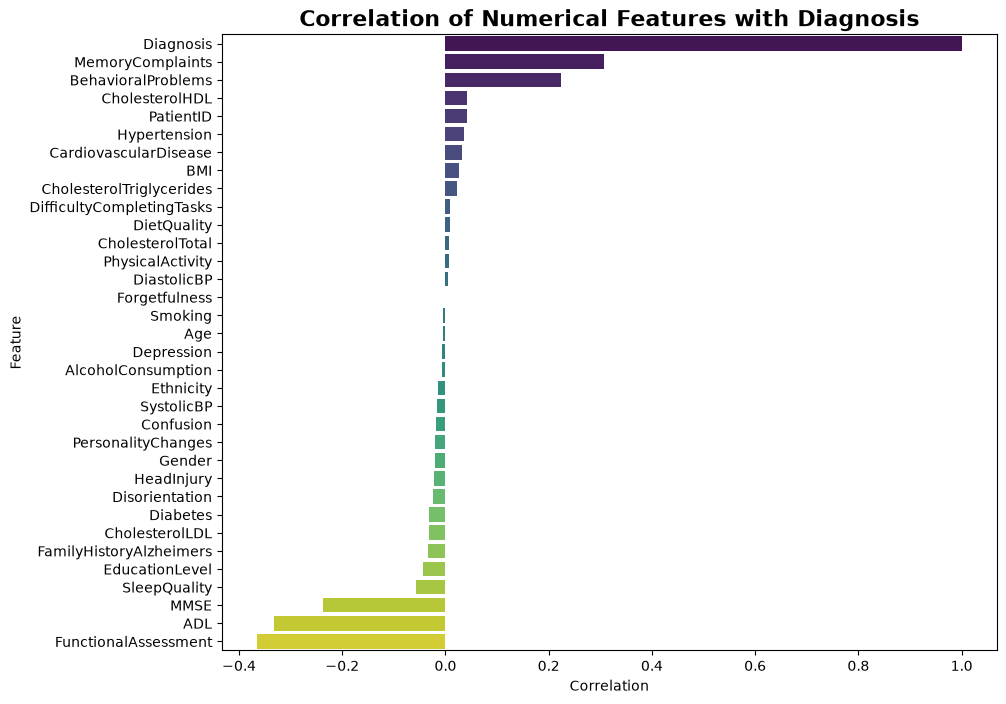

In [33]:
plt.figure(figsize=(10, 8))
sns.barplot(
    x=corr_with_churn.values,
    y=corr_with_churn.index,
    palette="viridis"
)
plt.title("Correlation of Numerical Features with Diagnosis", fontsize=16, fontweight='bold')
plt.xlabel("Correlation")
plt.ylabel("Feature")
plt.savefig("numchurn.jpeg")
plt.show()


### Observation

- **FunctionalAssessment (-0.36)**, **ADL (-0.33)**, and **MMSE (-0.24)** exhibit the strongest negative correlations with Alzheimer's diagnosis, indicating that lower cognitive and functional assessment scores are associated with a higher likelihood of Alzheimer's disease.
- **MemoryComplaints (0.31)** and **BehavioralProblems (0.22)** show the strongest positive correlations with the target variable, highlighting their importance as potential predictors.
- Most demographic, lifestyle, and cardiovascular-related variables exhibit weak correlations (|r| < 0.10), suggesting limited individual predictive power.
- Cognitive, functional, and symptom-related features appear to be more strongly associated with Alzheimer's diagnosis than general health indicators.
- Correlation measures only linear relationships; therefore, features with low correlation should not be discarded without further evaluation during model training.

In [41]:
df['DoctorInCharge'].value_counts()

DoctorInCharge
XXXConfid    2149
Name: count, dtype: int64

In [42]:
df['PatientID'].nunique()

2149

### Feature Removal Candidates

- PatientID is a unique identifier and does not provide predictive information.
- DoctorInCharge contains administrative information and is unlikely to contribute to diagnosis prediction.
- Both features will be removed during preprocessing.

# Key Findings from EDA

1. Dataset contains 2,149 patient records and 35 features.
2. No missing values or major data quality issues were identified.
3. The target variable is moderately imbalanced (64.6% vs 35.4%).
4. PatientID and DoctorInCharge are non-predictive features.
5. Cognitive and functional assessment features (MMSE, ADL, FunctionalAssessment) show the strongest relationship with Alzheimer's diagnosis.
6. Symptom-based features demonstrate significant predictive potential.
7. Several symptom-related variables may introduce target leakage in an Early Risk Detection model.
8. Health indicators such as BMI, Blood Pressure, and Cholesterol show relatively weak individual correlations with the target.